In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

df = pd.read_csv(
    OUT / "sparrow_model_data.csv",
    dtype={"ID": str}
)

train = df.loc[df["Split"] == "train"].copy()
test = df.loc[df["Split"] == "test"].copy()

features = [
    "BuildingHeight",
    "BuildingWidth",
    "Altitude",
    "AveNoise",
    "temp",
    "prec",
    "win"
]

X_train = train[features]
X_test = test[features]

assert set(train["ID"]).isdisjoint(set(test["ID"]))
assert set(train["SourceRowIndex"]).isdisjoint(
    set(test["SourceRowIndex"])
)
assert not X_train.isna().any().any()
assert not X_test.isna().any().any()

print("Training rows:", len(train))
print("Final test rows:", len(test))
print("Spatial group overlap: 0")

Training rows: 501
Final test rows: 156
Spatial group overlap: 0


In [2]:
# train classification model
y_train_cls = train["HigherNestCount"]
y_test_cls = test["HigherNestCount"]

classifier = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)

classifier.fit(X_train, y_train_cls)

cls_pred = classifier.predict(X_test)

positive_index = list(classifier.classes_).index(1)
cls_prob = classifier.predict_proba(X_test)[:, positive_index]

cls_baseline = DummyClassifier(strategy="most_frequent")
cls_baseline.fit(X_train, y_train_cls)

base_cls_pred = cls_baseline.predict(X_test)
base_positive_index = list(cls_baseline.classes_).index(1)
base_cls_prob = cls_baseline.predict_proba(X_test)[
    :, base_positive_index
]

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline Most Frequent,0.436,0.000,0.00,0.000,0.500
1,Decision Tree,0.551,0.579,0.75,0.653,0.505


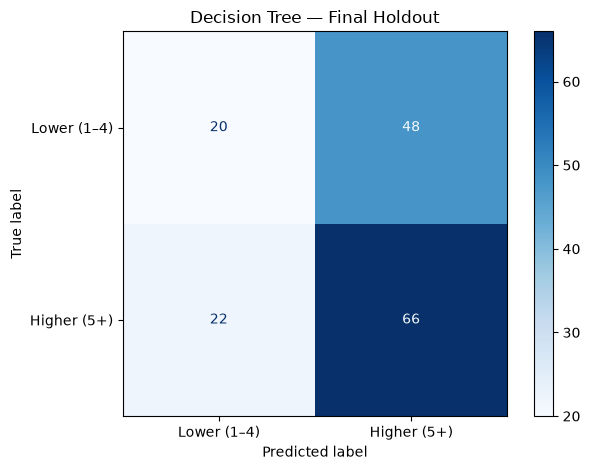

In [3]:
# classification metrics and confusion matrix
def classification_scores(name, actual, predicted, probability):
    return {
        "Model": name,
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(
            actual, predicted, zero_division=0
        ),
        "Recall": recall_score(
            actual, predicted, zero_division=0
        ),
        "F1": f1_score(actual, predicted, zero_division=0),
        "ROC_AUC": roc_auc_score(actual, probability)
    }

classification_test = pd.DataFrame([
    classification_scores(
        "Baseline Most Frequent",
        y_test_cls,
        base_cls_pred,
        base_cls_prob
    ),
    classification_scores(
        "Decision Tree",
        y_test_cls,
        cls_pred,
        cls_prob
    )
])

display(classification_test.round(3))

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    cls_pred,
    labels=[0, 1],
    display_labels=["Lower (1–4)", "Higher (5+)"],
    cmap="Blues",
    values_format="d"
)

plt.title("Decision Tree — Final Holdout")
plt.tight_layout()
plt.savefig(OUT / "final_confusion_matrix.png", dpi=200)
plt.show()

In [4]:
# compare regression model and baseline
y_train_reg = train["NestCount"]
y_test_reg = test["NestCount"]

regressor = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)

regressor.fit(X_train, y_train_reg)
reg_pred = regressor.predict(X_test)

regression_rows = []

for name, model in {
    "Baseline Mean": DummyRegressor(strategy="mean"),
    "Baseline Median": DummyRegressor(strategy="median")
}.items():
    model.fit(X_train, y_train_reg)
    pred = model.predict(X_test)

    regression_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_reg, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, pred)),
        "R2": r2_score(y_test_reg, pred)
    })

regression_rows.append({
    "Model": "Decision Tree",
    "MAE": mean_absolute_error(y_test_reg, reg_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, reg_pred)),
    "R2": r2_score(y_test_reg, reg_pred)
})

regression_test = pd.DataFrame(regression_rows)
display(regression_test.round(3))

,Model,MAE,RMSE,R2
0,Baseline Mean,3.190,4.550,-0.005
1,Baseline Median,3.276,4.953,-0.190
2,Decision Tree,4.095,5.698,-0.575


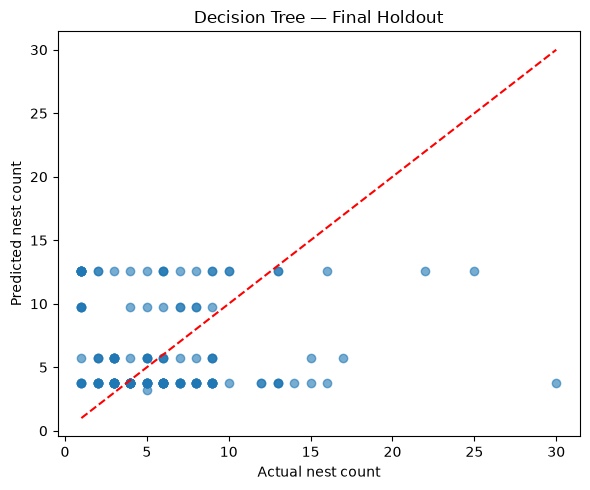

In [5]:
# final regression prediction
plt.figure(figsize=(6, 5))
plt.scatter(y_test_reg, reg_pred, alpha=0.6)

low = min(float(y_test_reg.min()), float(reg_pred.min()))
high = max(float(y_test_reg.max()), float(reg_pred.max()))

plt.plot([low, high], [low, high], "r--")
plt.xlabel("Actual nest count")
plt.ylabel("Predicted nest count")
plt.title("Decision Tree — Final Holdout")

plt.tight_layout()
plt.savefig(OUT / "final_regression_predictions.png", dpi=200)
plt.show()

In [6]:
# stroe final result
classification_test.to_csv(
    OUT / "classification_final_test_results.csv",
    index=False
)

regression_test.to_csv(
    OUT / "regression_final_test_results.csv",
    index=False
)

final_predictions = test[
    ["SourceRowIndex", "Building#", "ID",
     "NestCount", "HigherNestCount"]
].copy()

final_predictions["PredictedHigherNestCount"] = cls_pred
final_predictions["HigherNestCountProbability"] = cls_prob
final_predictions["PredictedNestCount"] = reg_pred
final_predictions["RegressionResidual"] = (
    y_test_reg.to_numpy() - reg_pred
)

final_predictions.to_csv(
    OUT / "final_test_predictions.csv",
    index=False
)

print("Final evaluation results saved.")

Final evaluation results saved.


In [7]:
import json
import joblib
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# These models were fitted using the 501 training rows.
joblib.dump(
    classifier,
    MODEL_DIR / "classification_tree.joblib"
)

joblib.dump(
    regressor,
    MODEL_DIR / "regression_tree.joblib"
)

# Training ranges are for UI guidance.
# Being within these ranges does not guarantee a reliable prediction.
feature_ranges = {
    feature: {
        "min": float(train[feature].min()),
        "max": float(train[feature].max()),
        "median": float(train[feature].median())
    }
    for feature in features
}

metadata = {
    "features": features,
    "classification_target": "NestCount >= 5",
    "regression_target": "NestCount",
    "training_rows": len(train),
    "test_rows": len(test),
    "feature_ranges": feature_ranges,
    "usage": "Educational prediction demo",
    "limitations": [
        "Data originate from China, not Myanmar.",
        "Data do not measure breeding success.",
        "Classification holdout ROC-AUC is approximately 0.505.",
        "Regression performed worse than the mean baseline."
    ]
}

with open(
    MODEL_DIR / "model_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(metadata, file, indent=2, ensure_ascii=False)

print("Saved models and metadata:")
for path in sorted(MODEL_DIR.iterdir()):
    print(path.name)

Saved models and metadata:
classification_tree.joblib
model_metadata.json
regression_tree.joblib
